In [1]:
%matplotlib widget

In [12]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-02-017/MGC+01-02-017_1/FORS2.2021-10-04T04_41_52.988/MCG+01-02-017_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-02-017/MGC+01-02-017_1/FORS2.2021-10-04T04_41_52.988/MCG+01-02-017_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 963)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 963)   float32   


In [4]:
image_cut = image[61:161, 0:1890]
image_error_cut = image_error[61:161, 0:1890]

Text(0.5, 0, 'wavelength')

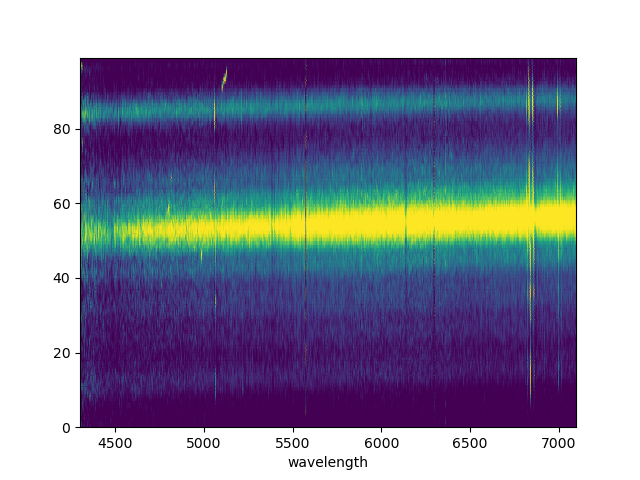

In [5]:
wavelengths = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelengths, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 20), vmax=np.percentile(image_cut, 95))
plt.xlabel('wavelength')

In [6]:
z = 0.0429
l_HA_z = 6563 * (1+z)
l_HB_z = 4861 * (1+z) 
l_NII_z = 6583 * (1+z)
l_SII_z = 6717 * (1+z)
l_OIII_z = 5007 * (1+z)
#Non combaciano 
l_HA = 6838
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-02-017/PSF/Real_seeing_MCG+01-02-017.txt")
sigma = seeing[0] / 2.35

In [7]:
l_HA

6838

Text(0.5, 1.0, 'H$\\alpha$')

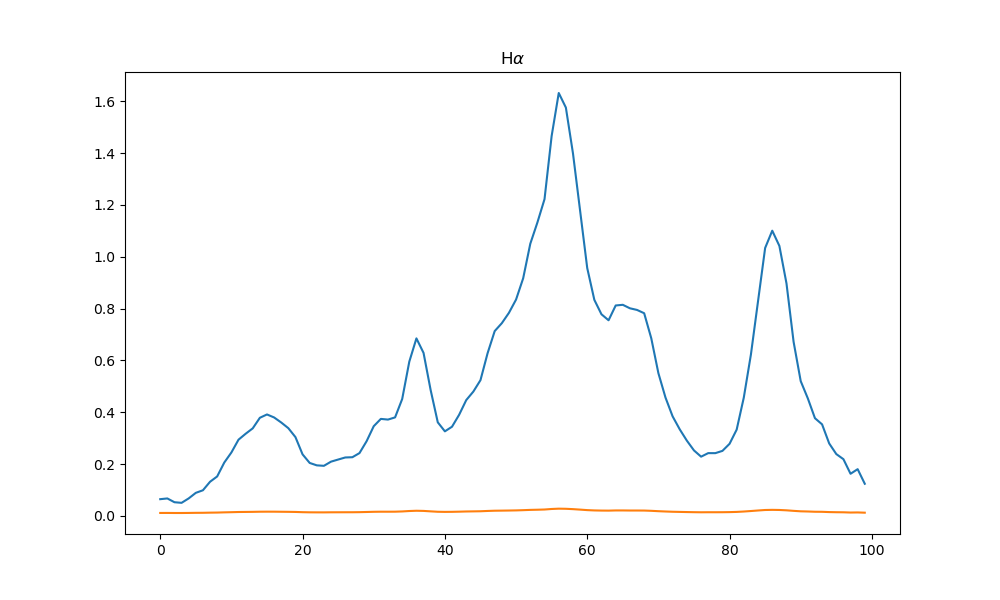

In [8]:
#Ogni punto del flusso è il risultato della somma di 20 lunghezze d'onda 
mask_HA = (wavelengths > l_HA-8)*(wavelengths < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [9]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

#Define the function for the aic
#Per l'AIC test usiamo il chi quadro perchè il numero di conteggi è elevato (S/N grande) 
#quindi Poisson --> Gauss
#def chi_quad(x, y, y_err, params):
#    return np.sum((((y - model_convolved(x, *params)) / y_err)**2))
    
def AIC(x, y, chi, params): #k=number of model parameter, N=number of data points
    return chi + 2*len(params) +((2*len(params)*(len(params)+1))/(len(y)-len(params)-1))

def BIC(x, y, chi, params):
        return chi + len(params)*np.log(len(y))
    
def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def save_params(params_curve, covariance, radial_profile, radial_profile_error, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, chi2

In [10]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params) 
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (53, 58),  # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params1 = result.x

print("Optimize parameters with differential_evolution:", best_params1)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 10.809658610425137
differential_evolution step 2: f(x)= 10.809658610425137
differential_evolution step 3: f(x)= 6.576984860520602
differential_evolution step 4: f(x)= 6.576984860520602
differential_evolution step 5: f(x)= 5.605426041001009
differential_evolution step 6: f(x)= 5.209529762964496
differential_evolution step 7: f(x)= 5.209529762964496
differential_evolution step 8: f(x)= 5.209529762964496
differential_evolution step 9: f(x)= 5.146199753523608
differential_evolution step 10: f(x)= 5.009785098399206
differential_evolution step 11: f(x)= 4.830064192325485
differential_evolution step 12: f(x)= 4.246651611143232
differential_evolution step 13: f(x)= 4.246651611143232
differential_evolution step 14: f(x)= 4.246651611143232
differential_evolution step 15: f(x)= 4.246651611143232
differential_evolution step 16: f(x)= 4.246651611143232
differential_evolution step 17: f(x)= 4.246651611143232
differential_evolution step 18: f(x)= 4.165232776155935

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0116, r_e=410.3031, n=2.9631, x_0=56.3698
[2.70178937e-02 8.13481080e+02 1.63161649e+00 5.17261165e-03]
97.78360974483822
106.20466237641716 0.0 116.20429048879058 4


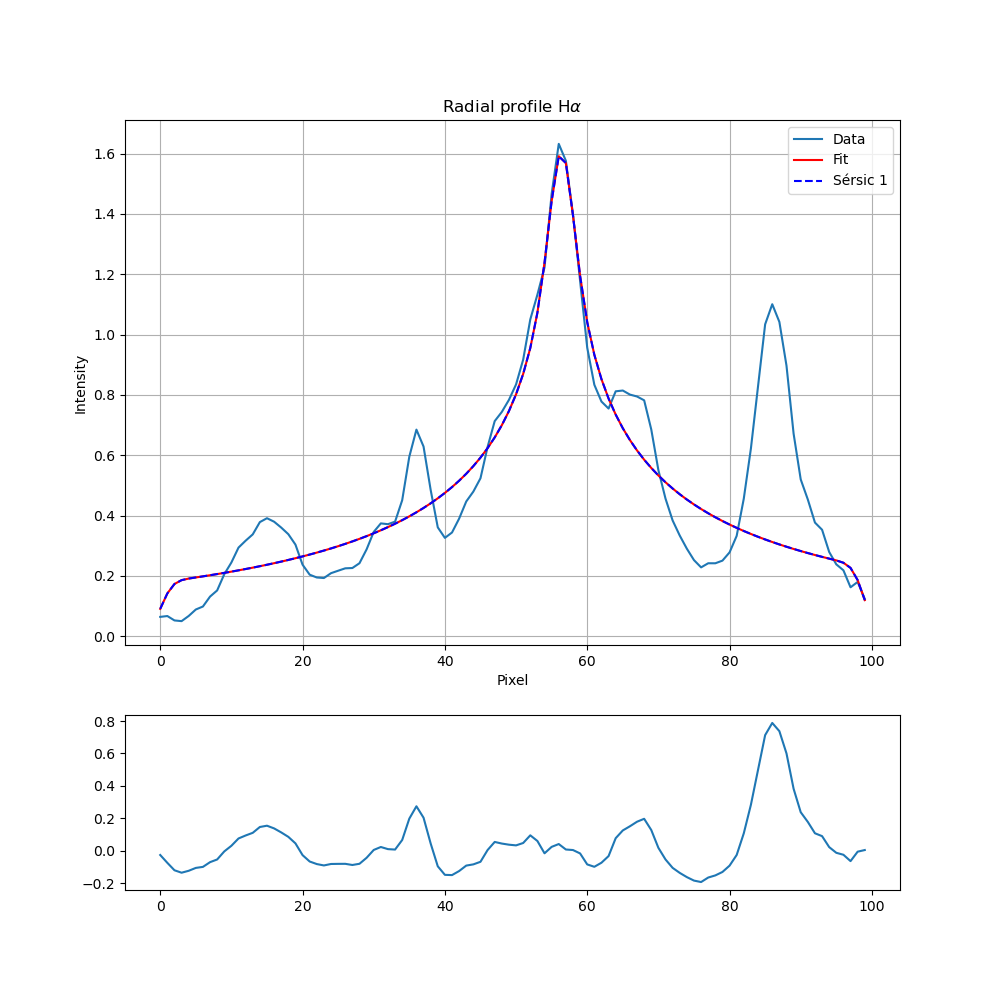

In [13]:
# Plots:
aic = np.zeros(7)
bic = np.zeros(7)
chi_quadr = np.zeros(7)
chi_quadro = np.zeros(7)
red_chi = np.zeros(7)

params_curve_1, covariance_1 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params1,
                                         sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[0], red_chi[0] = save_params(params_curve_1, covariance_1, radial_profile_HA, radial_profile_error_HA, x_axes, 1, line_name="One", 
                                           output_prefix="fit")

aic[0] = AIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
bic[0] = BIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
print(aic[0], chi_quadro[0], bic[0], len(params_curve_1))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_1)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_1), 'b--', label='Sérsic 1')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_1', bbox_inches='tight')

In [14]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =  [
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (53, 58),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (83, 89),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params2 = result.x

print("Optimize parameters with differential_evolution:", best_params2)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 111.31156389289487
differential_evolution step 2: f(x)= 111.31156389289487
differential_evolution step 3: f(x)= 102.68151651350873
differential_evolution step 4: f(x)= 9.979054212301712
differential_evolution step 5: f(x)= 9.979054212301712
differential_evolution step 6: f(x)= 4.998036107580242
differential_evolution step 7: f(x)= 4.998036107580242
differential_evolution step 8: f(x)= 4.998036107580242
differential_evolution step 9: f(x)= 4.998036107580242
differential_evolution step 10: f(x)= 4.998036107580242
differential_evolution step 11: f(x)= 4.305942378908941
differential_evolution step 12: f(x)= 4.305942378908941
differential_evolution step 13: f(x)= 2.666552195315764
differential_evolution step 14: f(x)= 2.666552195315764
differential_evolution step 15: f(x)= 2.6059533554008008
differential_evolution step 16: f(x)= 2.6059533554008008
differential_evolution step 17: f(x)= 2.178694806472592
differential_evolution step 18: f(x)= 2.178694806472

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0220, r_e=195.6359, n=2.6093, x_0=56.1139
Sérsic 2: I_e=0.4884, r_e=2.4772, n=0.4929, x_0=86.4424
[1.34579114e-02 1.03449949e+02 4.04545912e-01 2.66347181e-01
 2.34444727e-01 4.73225145e-01 3.77060828e-01 2.37926057e-01]
37.08095792389502
54.663375506312605 37.08095792389502 73.92231941179975 8


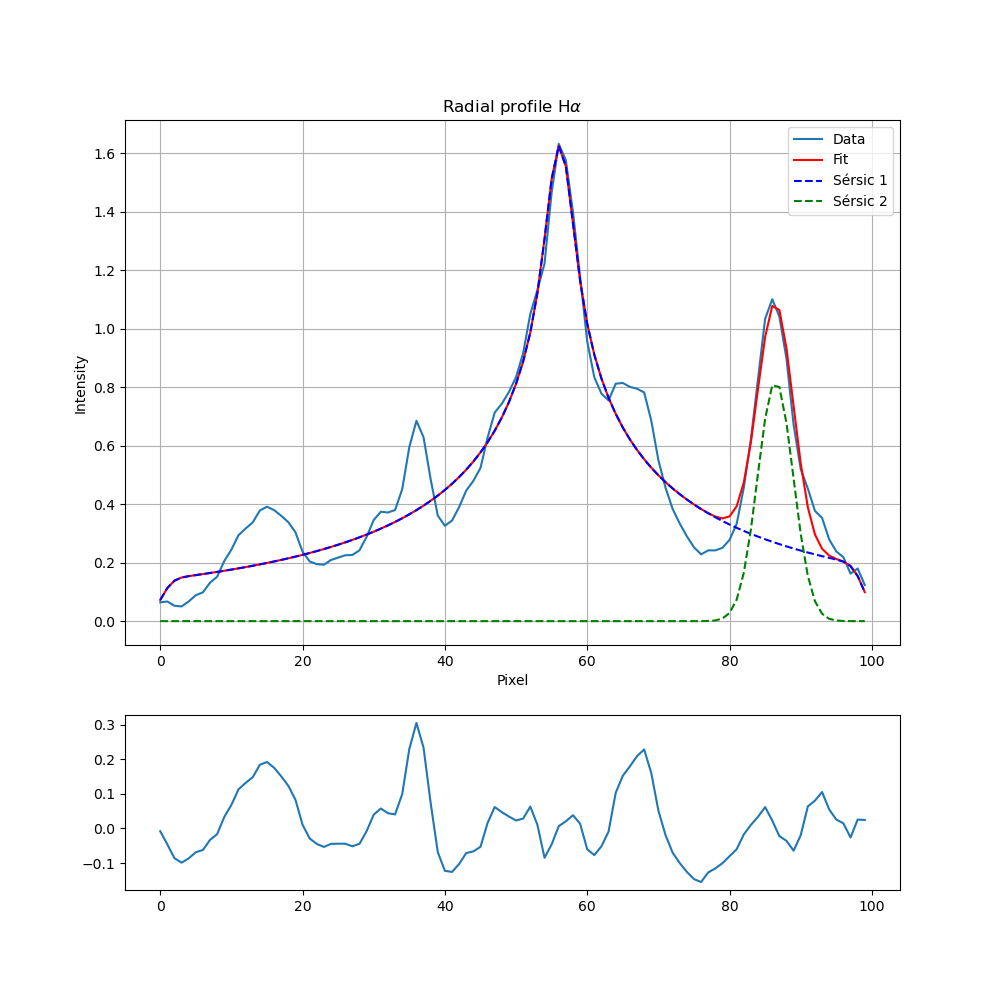

In [15]:
# Plots:
params_curve_2, covariance_2 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params2, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[1], red_chi[1] = save_params(params_curve_2, covariance_2, radial_profile_HA, radial_profile_error_HA,
    x_axes, 2, line_name="Two", output_prefix="fit")

aic[1] = AIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
bic[1] = BIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
print(aic[1], chi_quadr[1], bic[1], len(params_curve_2))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_2)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[4:8]), 'g--', label='Sérsic 2')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_2', bbox_inches='tight')

In [16]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (53, 58),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (83, 89),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (13, 18),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params3 = result.x

print("Optimize parameters with differential_evolution:", best_params3)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 7215.50823352786
differential_evolution step 2: f(x)= 702.636709444088
differential_evolution step 3: f(x)= 702.636709444088
differential_evolution step 4: f(x)= 702.636709444088
differential_evolution step 5: f(x)= 224.09147715858322
differential_evolution step 6: f(x)= 197.6890964246751
differential_evolution step 7: f(x)= 52.37154820696317
differential_evolution step 8: f(x)= 52.37154820696317
differential_evolution step 9: f(x)= 52.37154820696317
differential_evolution step 10: f(x)= 52.37154820696317
differential_evolution step 11: f(x)= 52.37154820696317
differential_evolution step 12: f(x)= 15.070224803269682
differential_evolution step 13: f(x)= 15.070224803269682
differential_evolution step 14: f(x)= 4.281114635977031
differential_evolution step 15: f(x)= 4.281114635977031
differential_evolution step 16: f(x)= 4.281114635977031
differential_evolution step 17: f(x)= 4.281114635977031
differential_evolution step 18: f(x)= 4.281114635977031
di

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_17208\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_17208\1656088014.py:9: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0605, r_e=75.8611, n=1.9822, x_0=56.1223
Sérsic 2: I_e=0.4279, r_e=2.8418, n=0.5956, x_0=86.5147
Sérsic 3: I_e=0.1803, r_e=3.3504, n=0.2250, x_0=14.5001
[ 0.03359644 33.21484363  0.41422773  0.03985     0.15910577  0.49280253
  0.29082823  0.20237216  0.08089545  0.59607072  0.41142669  0.59711685]
26.661720404837148
54.24792730138887 26.661720404837148 81.92376263669425 12


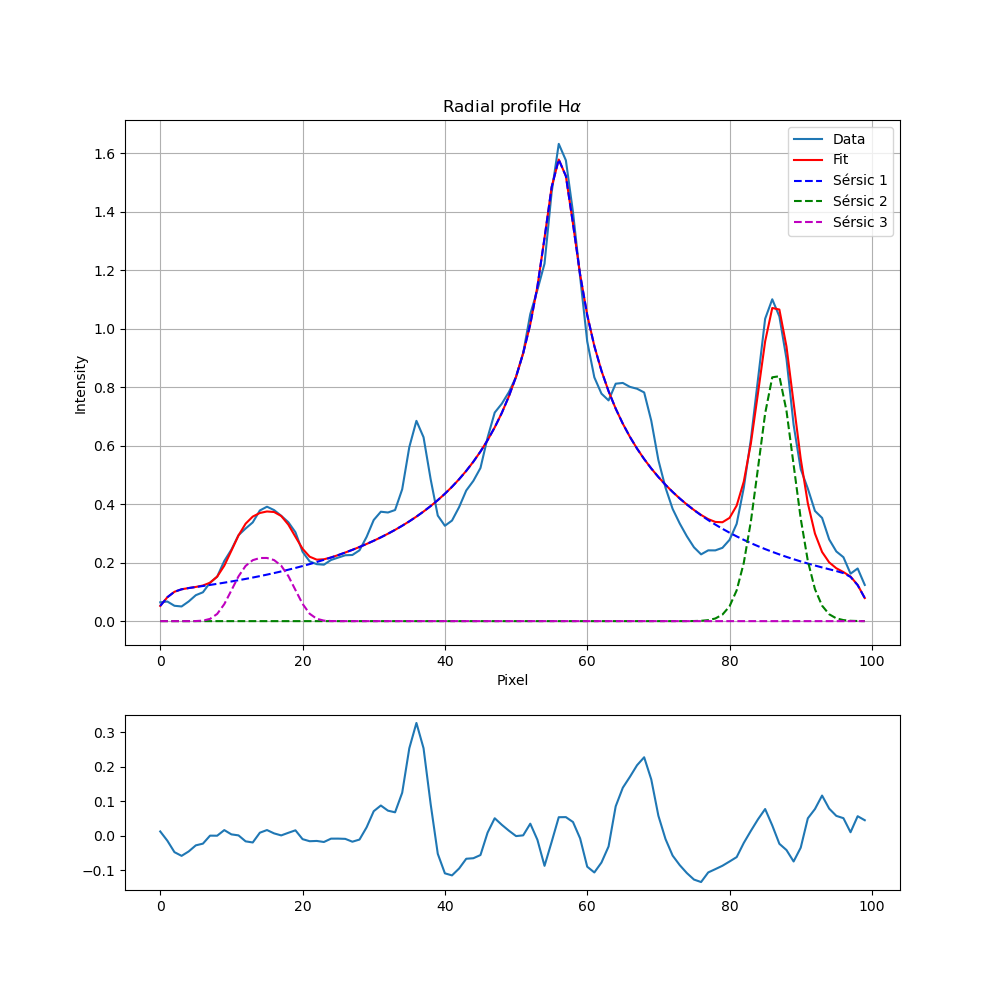

In [17]:
# Plots:
params_curve_3, covariance_3 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params3, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[2], red_chi[2] = save_params(params_curve_3, covariance_3, radial_profile_HA, radial_profile_error_HA,x_axes, 3,  
                                       line_name="Three", output_prefix="fit")

aic[2] = AIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
bic[2] = BIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
print(aic[2], chi_quadr[2], bic[2], len(params_curve_3))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_3)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[8:12]), 'm--', label='Sérsic 3')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_3', bbox_inches='tight')

In [18]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (53, 58),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (83, 89),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (13, 18),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (33, 38),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params4 = result.x

print("Optimize parameters with differential_evolution:", best_params4)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 16238.396713903985
differential_evolution step 2: f(x)= 12063.081787797026
differential_evolution step 3: f(x)= 12063.081787797026
differential_evolution step 4: f(x)= 830.3376244410214
differential_evolution step 5: f(x)= 830.3376244410214
differential_evolution step 6: f(x)= 830.3376244410214
differential_evolution step 7: f(x)= 830.3376244410214
differential_evolution step 8: f(x)= 830.3376244410214
differential_evolution step 9: f(x)= 830.3376244410214
differential_evolution step 10: f(x)= 799.479784131536
differential_evolution step 11: f(x)= 682.8980649361016
differential_evolution step 12: f(x)= 327.0844377947937
differential_evolution step 13: f(x)= 184.2282337507498
differential_evolution step 14: f(x)= 103.31455605556822
differential_evolution step 15: f(x)= 44.15051925928605
differential_evolution step 16: f(x)= 44.15051925928605
differential_evolution step 17: f(x)= 44.15051925928605
differential_evolution step 18: f(x)= 44.1505192592860

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0671, r_e=64.8528, n=1.9348, x_0=56.2213
Sérsic 2: I_e=0.3973, r_e=3.0853, n=0.6528, x_0=86.5404
Sérsic 3: I_e=0.1868, r_e=3.5915, n=0.2554, x_0=14.5006
Sérsic 4: I_e=0.2084, r_e=0.8785, n=1.1402, x_0=35.7430
[ 0.03013478 22.68235997  0.33897439  0.04807786  0.12017487  0.47418785
  0.23597422  0.16806761  0.06317869  0.52354853  0.2830778   0.46997077
  2.03701849  2.47671394 10.85312565  0.28417719]
18.38169119304799
56.93590806051786 18.38169119304799 92.06441416885745 16


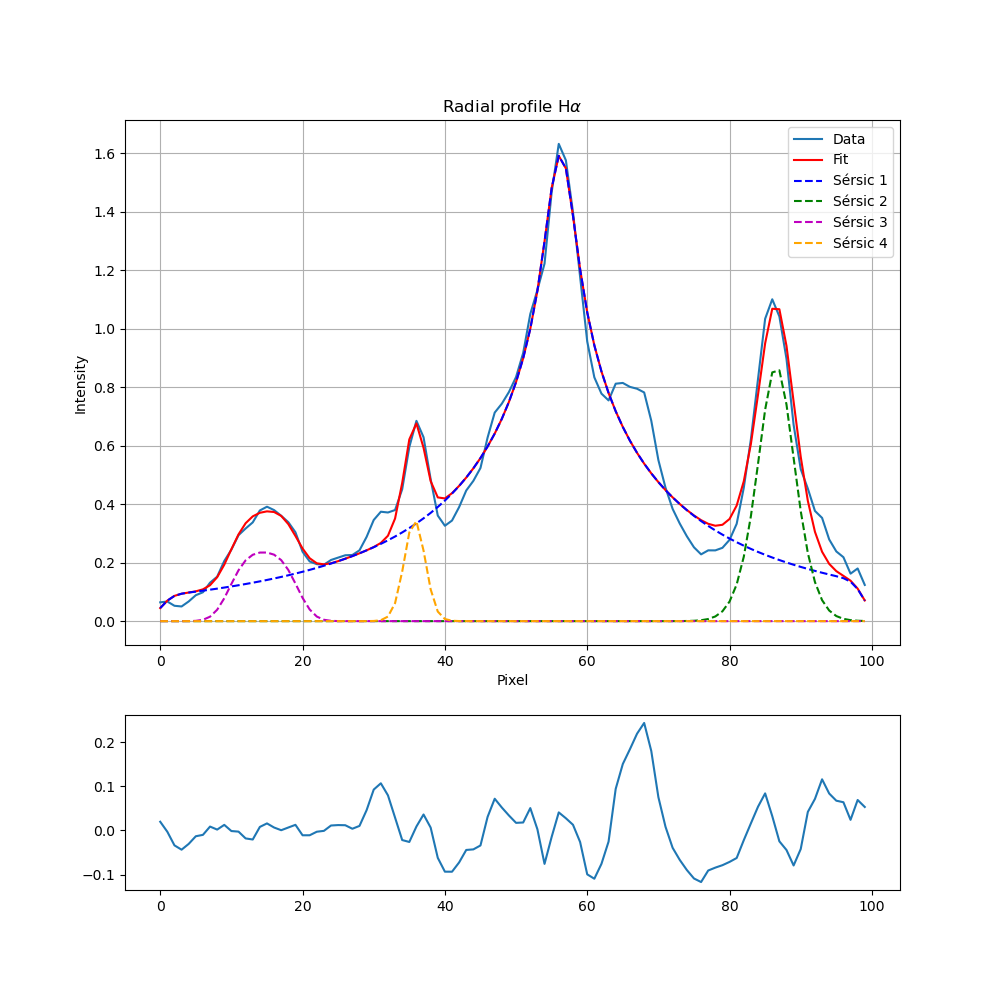

In [19]:
# Plots:
params_curve_4, covariance_4 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params4, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[3], red_chi[3] = save_params(params_curve_4, covariance_4, radial_profile_HA, radial_profile_error_HA, x_axes, 4, line_name="Four", output_prefix="fit")

aic[3] = AIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
bic[3] = BIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
print(aic[3], chi_quadr[3], bic[3], len(params_curve_4))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_4)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_4', bbox_inches='tight')

In [23]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (53, 58),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (83, 89),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (13, 18),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (33, 38), 

    (0, 10),
    (0, 50),
    (0.1, 10),
    (64, 66)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params5 = result.x

print("Optimize parameters with differential_evolution:", best_params5)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 248240.9777841183
differential_evolution step 2: f(x)= 57218.56414041811
differential_evolution step 3: f(x)= 57218.56414041811
differential_evolution step 4: f(x)= 28010.175092972553
differential_evolution step 5: f(x)= 16755.638286278125
differential_evolution step 6: f(x)= 6198.495539230433
differential_evolution step 7: f(x)= 6198.495539230433
differential_evolution step 8: f(x)= 6198.495539230433
differential_evolution step 9: f(x)= 6198.495539230433
differential_evolution step 10: f(x)= 6198.495539230433
differential_evolution step 11: f(x)= 6198.495539230433
differential_evolution step 12: f(x)= 6198.495539230433
differential_evolution step 13: f(x)= 2815.2099647828627
differential_evolution step 14: f(x)= 702.9238117708733
differential_evolution step 15: f(x)= 702.9238117708733
differential_evolution step 16: f(x)= 702.9238117708733
differential_evolution step 17: f(x)= 702.9238117708733
differential_evolution step 18: f(x)= 228.920764156156

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_17208\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_17208\2155415607.py:11: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.3895, r_e=8.8238, n=0.8457, x_0=55.8792
Sérsic 2: I_e=0.0584, r_e=17.6616, n=2.0140, x_0=86.3322
Sérsic 3: I_e=0.1788, r_e=3.9322, n=0.3420, x_0=14.5400
Sérsic 4: I_e=0.0045, r_e=282.0542, n=2.9583, x_0=35.6242
Sérsic 5: I_e=0.2850, r_e=2.7038, n=0.3694, x_0=67.5594
[4.81254153e-02 8.78462723e-01 8.42884547e-02 1.57524618e-01
 3.73311877e-02 9.16420450e+00 4.50715257e-01 1.06368473e-01
 3.91260291e-02 4.85005471e-01 1.70784942e-01 3.19195169e-01
 1.20501030e-02 6.60404918e+02 1.86167266e+00 4.12698014e-03
 9.75940104e-02 4.54510026e-01 2.69496606e-01 2.63054772e-01]
7.572720790772392
58.20563218317746 7.572720790772392 99.67612451053424 20


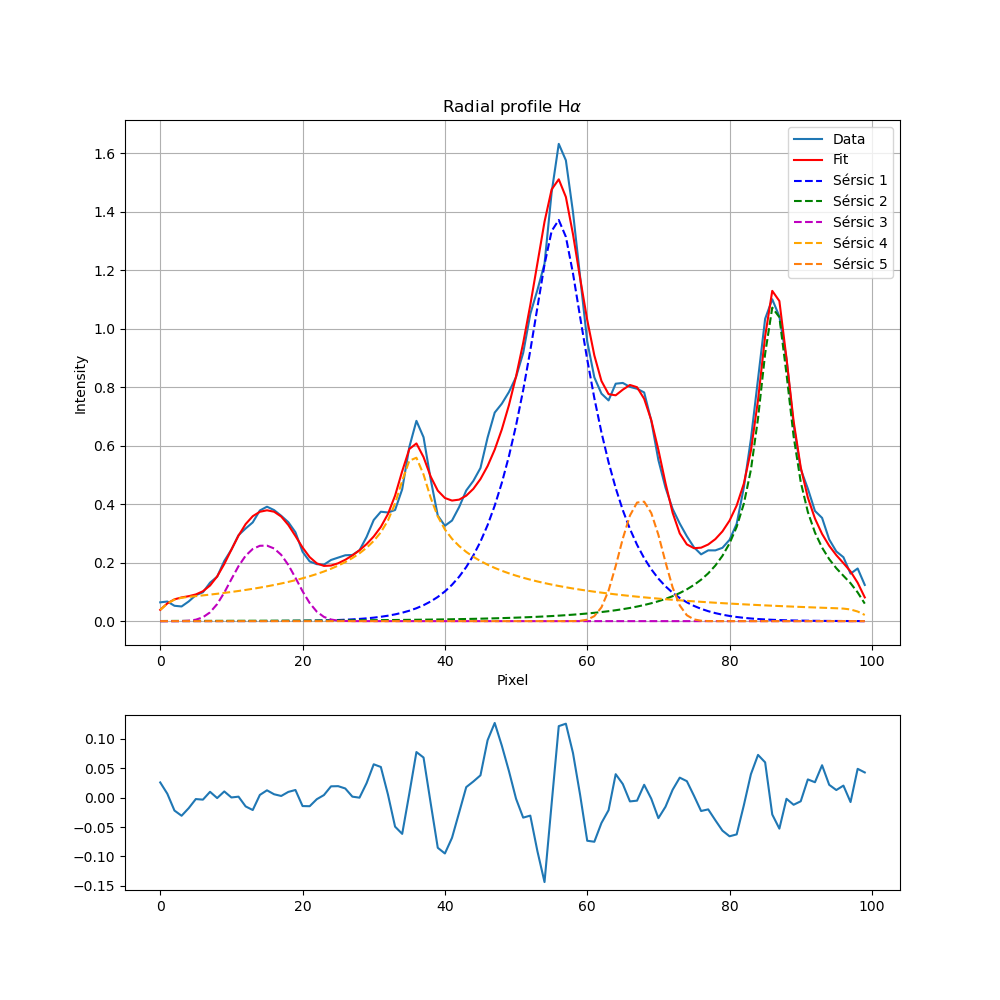

In [24]:
# Plots:
params_curve_5, covariance_5 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params5, 
                                         sigma = radial_profile_error_HA, maxfev = 10000)

print("Optimize parameters with curve fit:")

chi_quadr[4], red_chi[4] = save_params(params_curve_5, covariance_5, radial_profile_HA, radial_profile_error_HA, x_axes, 5, line_name="Five", output_prefix="fit")

aic[4] = AIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
bic[4] = BIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
print(aic[4], chi_quadr[4], bic[4], len(params_curve_5))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_5)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[16:20]),  linestyle='--', label='Sérsic 5')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_5', bbox_inches='tight')

In [27]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (53, 58),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (83, 89),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (13, 18),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (33, 38), 

    (0, 10),
    (0, 50),
    (0.1, 10),
    (63, 68),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params6 = result.x

print("Optimize parameters with differential_evolution:", best_params6)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 65337.23980368523
differential_evolution step 2: f(x)= 62945.87248122782
differential_evolution step 3: f(x)= 48740.48747156148
differential_evolution step 4: f(x)= 45356.99465760828
differential_evolution step 5: f(x)= 12630.379191849455
differential_evolution step 6: f(x)= 12630.379191849455
differential_evolution step 7: f(x)= 9242.776673646316
differential_evolution step 8: f(x)= 9242.776673646316
differential_evolution step 9: f(x)= 9242.776673646316
differential_evolution step 10: f(x)= 9242.776673646316
differential_evolution step 11: f(x)= 9242.776673646316
differential_evolution step 12: f(x)= 5532.57353686428
differential_evolution step 13: f(x)= 5532.57353686428
differential_evolution step 14: f(x)= 5532.57353686428
differential_evolution step 15: f(x)= 3625.0366100102115
differential_evolution step 16: f(x)= 2041.7744652300232
differential_evolution step 17: f(x)= 2041.7744652300232
differential_evolution step 18: f(x)= 2041.774465230023

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_17208\111436280.py:9: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution: [5.22542491e-02 1.28730062e+01 2.14661861e+00 5.62139195e+01
 4.22993468e-01 2.50314503e+00 6.35574231e-01 8.62223022e+01
 8.33671309e-02 3.96938973e+00 7.03488300e-01 1.40639301e+01
 6.44488346e+00 5.00515877e-02 5.97700270e-01 3.60839915e+01
 2.35199730e-01 3.95810407e+01 1.79537191e-01 6.34591275e+01
 3.51088086e-01 1.11456370e+01 1.00942466e-01 5.77624594e+01]
Chi quadro minimo: 0.1700749908671132


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_17208\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_17208\3718685306.py:12: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.4697, r_e=2.1543, n=0.5356, x_0=56.1288
Sérsic 2: I_e=0.3339, r_e=3.2685, n=0.7935, x_0=86.2450
Sérsic 3: I_e=0.1775, r_e=3.4941, n=0.2154, x_0=14.2682
Sérsic 4: I_e=0.0710, r_e=5.2055, n=1.3699, x_0=35.9212
Sérsic 5: I_e=0.1976, r_e=42.9021, n=0.1676, x_0=65.1833
Sérsic 6: I_e=0.5244, r_e=10.0085, n=0.1439, x_0=57.6877
[ 0.16745348  0.37395133  0.28557973  0.09846074  0.07979182  0.53577203
  0.18561135  0.0807354   0.0284406   0.30726743  0.17508659  0.25921857
  0.07703392  4.19525623  0.80175969  0.15115601  0.01594422 10.63635441
  0.09169853 12.23526362  0.03042517  0.50059859  0.02596233  0.20279789]
3.981506518191251
67.98150651819125 3.981506518191251 114.50559098190546 24


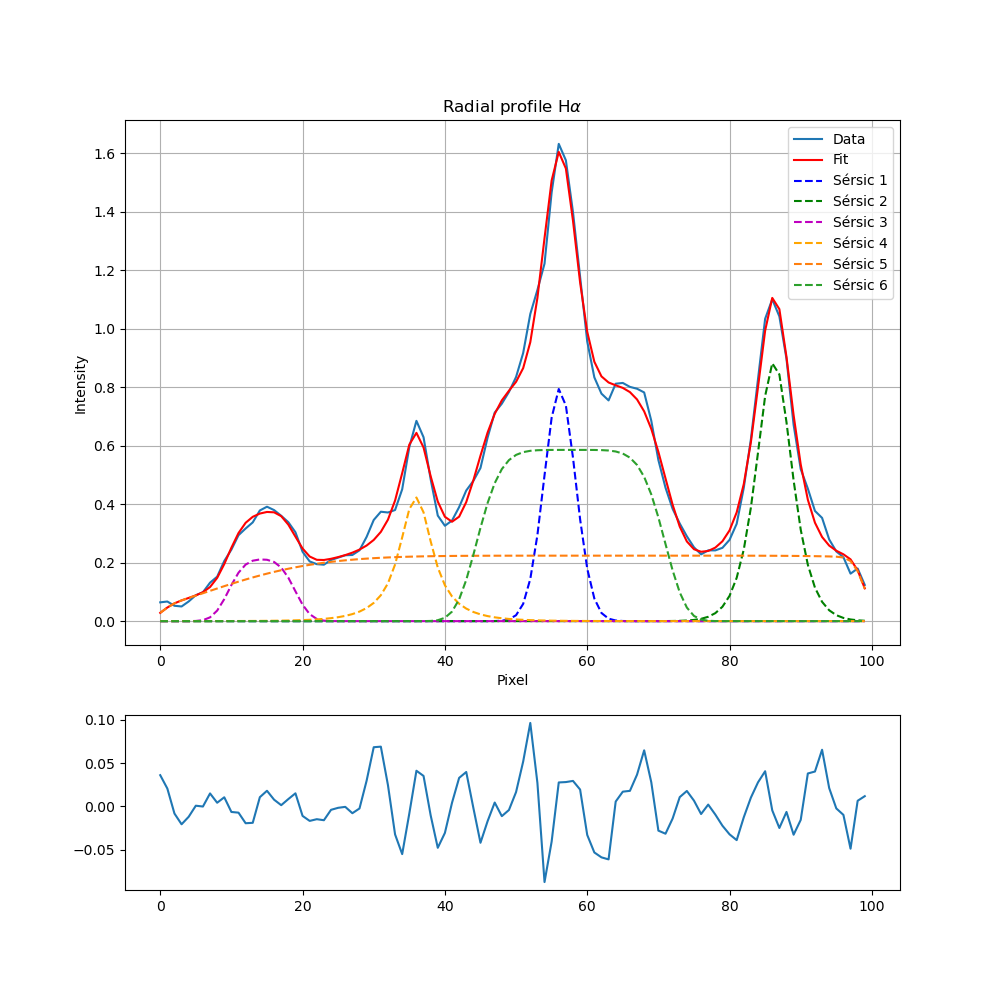

In [28]:
# Plots:
params_curve_6, covariance_6 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params6, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[5], red_chi[5] = save_params(params_curve_6, covariance_6, radial_profile_HA, radial_profile_error_HA, x_axes, 6, line_name="Six", output_prefix="fit")

aic[5] = AIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
bic[5] = BIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
print(aic[5], chi_quadr[5], bic[5], len(best_params6))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_6)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[20:24]),  linestyle='--', label='Sérsic 6')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_6', bbox_inches='tight')

In [29]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24]) +
        sersic_1d(x_hr, *params[24:28])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (53, 58),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (83, 89),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (13, 18),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (33, 38), 

    (0, 10),
    (0, 50),
    (0.1, 10),
    (63, 68),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params7 = result.x

print("Optimize parameters with differential_evolution:", best_params7)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 234511.5953475667
differential_evolution step 2: f(x)= 234511.5953475667
differential_evolution step 3: f(x)= 61385.49808866687
differential_evolution step 4: f(x)= 61385.49808866687
differential_evolution step 5: f(x)= 61385.49808866687
differential_evolution step 6: f(x)= 61385.49808866687
differential_evolution step 7: f(x)= 61385.49808866687
differential_evolution step 8: f(x)= 61385.49808866687
differential_evolution step 9: f(x)= 61385.49808866687
differential_evolution step 10: f(x)= 29066.363478156163
differential_evolution step 11: f(x)= 25866.41355458248
differential_evolution step 12: f(x)= 25866.41355458248
differential_evolution step 13: f(x)= 25866.41355458248
differential_evolution step 14: f(x)= 25866.41355458248
differential_evolution step 15: f(x)= 13168.821756589885
differential_evolution step 16: f(x)= 13168.821756589885
differential_evolution step 17: f(x)= 13168.821756589885
differential_evolution step 18: f(x)= 13168.821756589

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_17208\111436280.py:9: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution: [2.08014340e-01 1.01862143e+01 1.25137994e+00 5.64361001e+01
 1.18899277e-01 9.93422256e+00 1.52127659e+00 8.63773567e+01
 6.23639319e-02 1.06424801e+01 1.11763654e+00 1.49438354e+01
 2.38332477e-02 8.25508846e+00 2.36522624e+00 3.55843509e+01
 3.29479069e-01 2.77341969e+00 2.70217115e-01 6.72795770e+01
 3.63576967e-02 4.96219007e+01 1.51829905e+00 4.93712206e+01
 4.81454766e+00 1.81937435e-05 4.71063092e+00 3.09204893e+01]
Chi quadro minimo: 0.11381130362234593


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_17208\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_17208\698150684.py:13: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.3865, r_e=5.2341, n=0.8612, x_0=56.3490
Sérsic 2: I_e=0.0779, r_e=12.8202, n=1.8216, x_0=86.3546
Sérsic 3: I_e=0.1214, r_e=5.2270, n=0.6328, x_0=14.8863
Sérsic 4: I_e=0.0100, r_e=7.1234, n=3.6752, x_0=35.8965
Sérsic 5: I_e=0.3094, r_e=3.3900, n=0.4457, x_0=66.9312
Sérsic 6: I_e=0.0319, r_e=75.1151, n=1.7549, x_0=48.0825
Sérsic 7: I_e=5.2556, r_e=0.0000, n=7.8197, x_0=30.9205
[2.68175855e-01 3.89874151e+00 4.61031896e-01 1.40968226e-01
 3.82204374e-02 5.50436801e+00 3.45966178e-01 8.84848049e-02
 3.65068252e-02 1.58068369e+00 2.36833738e-01 2.75756307e-01
 2.73814440e-01 1.23187399e+02 3.93112703e+01 9.03972791e-03
 8.90787920e-02 5.31687624e-01 1.39506654e-01 5.87821104e-01
 3.36659093e-02 5.99896557e+01 4.88395538e-01 6.23605470e-01
 3.77199382e+06 1.43762755e+01 6.24570772e+06 6.89360250e+00]
4.334912894471197
83.20815233109091 4.334912894471197 133.27967810213775 28


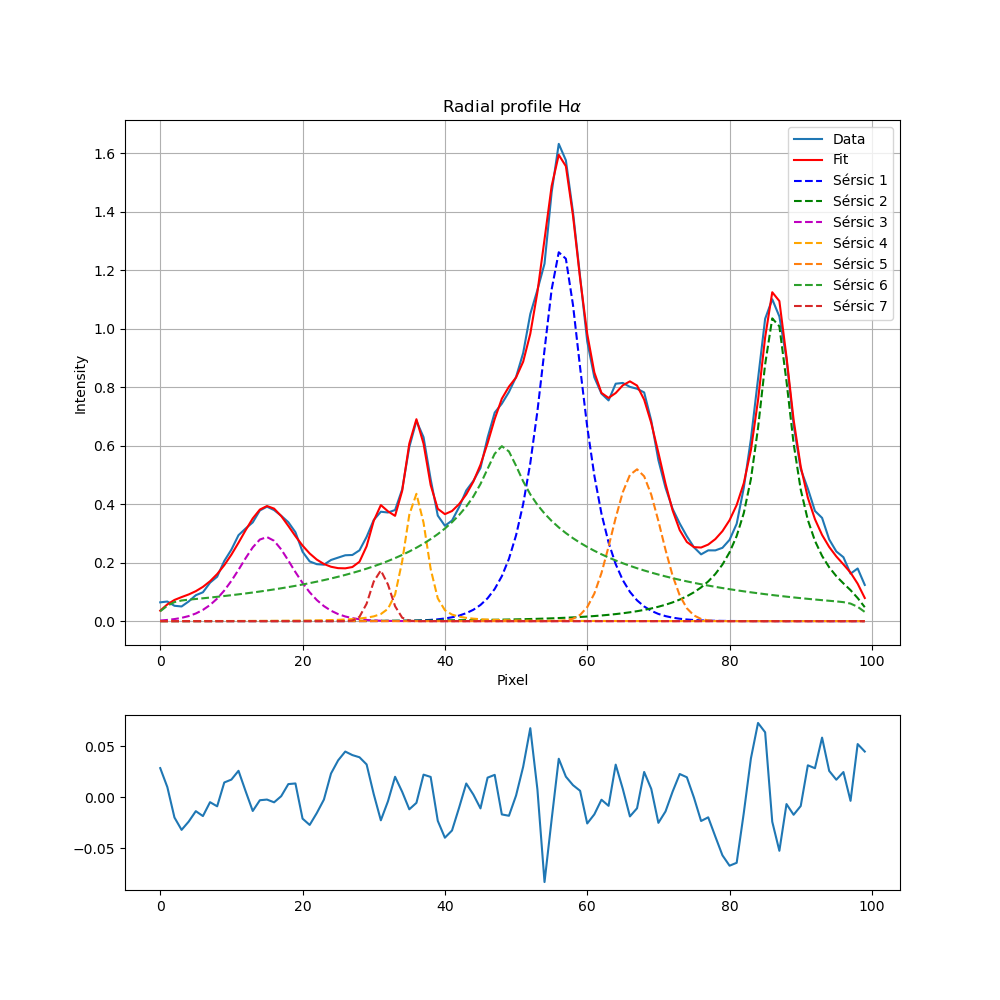

In [30]:
# Plots:
params_curve_7, covariance_7 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params7, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[6], red_chi[6] = save_params(params_curve_7, covariance_7, radial_profile_HA, radial_profile_error_HA, x_axes, 7, 
                                       line_name="Seven", output_prefix="fit")

aic[6] = AIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
bic[6] = BIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
print(aic[6], chi_quadr[6], bic[6], len(best_params7))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_7)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[20:24]),  linestyle='--', label='Sérsic 6')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[24:28]),  linestyle='--', label='Sérsic 7')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_7', bbox_inches='tight')

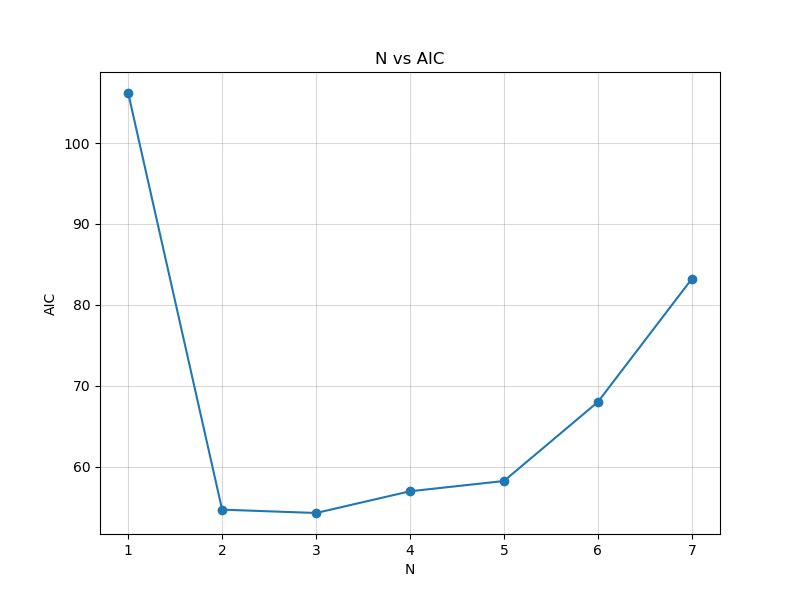

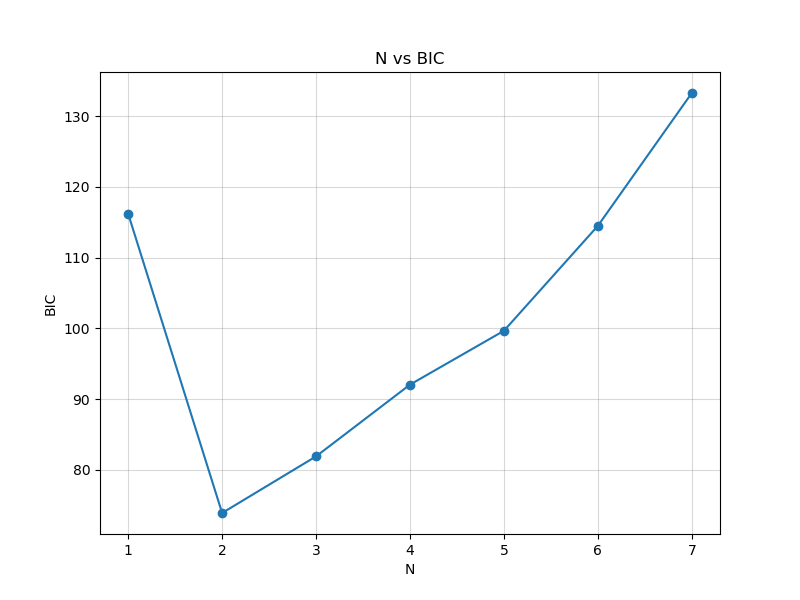

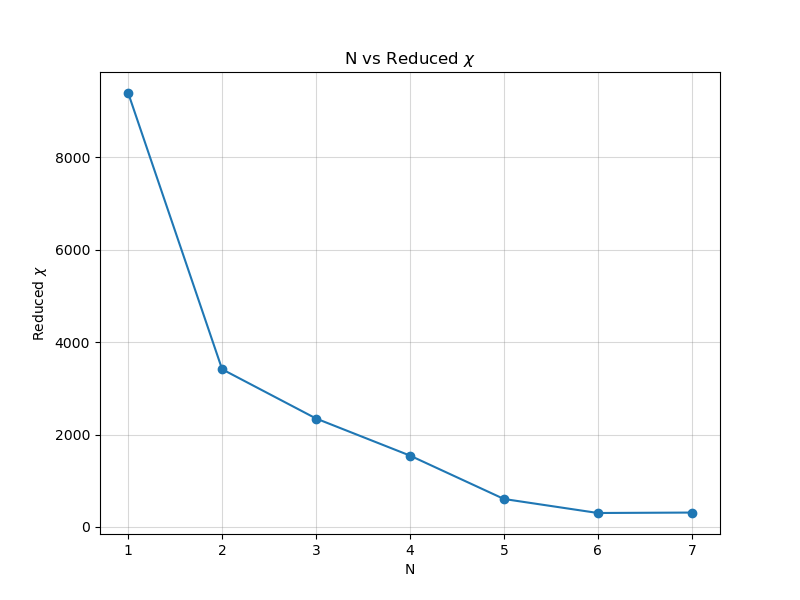

In [31]:
#Plot AIC vs N 
n = [1, 2, 3, 4, 5, 6, 7]

fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('AIC')
ax1.set_title('N vs AIC')
ax1.plot(n, aic, marker = 'o')
plt.savefig('AIC_vs_N', bbox_inches='tight')
np.savetxt('AIC', aic)
np.savetxt('Reduced_chi', red_chi)

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('BIC')
ax2.set_title('N vs BIC')
ax2.plot(n, bic, marker = 'o')
plt.savefig('BIC_vs_N', bbox_inches='tight')
np.savetxt('BIC', aic)

fig3 = plt.figure(figsize=(8,6))
ax3 = fig3.gca()
ax3.grid(alpha=0.3, c = 'grey')
ax3.set_xlabel('N')
ax3.set_ylabel('Reduced $\chi$')
ax3.set_title('N vs Reduced $\chi$')
ax3.plot(n, red_chi, marker = 'o')
plt.savefig('Reduced_chi_vs_N', bbox_inches='tight')

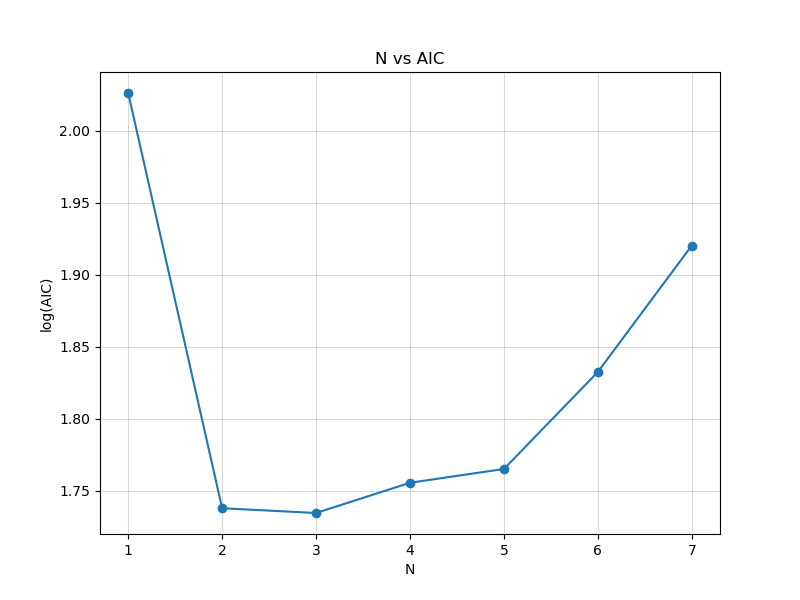

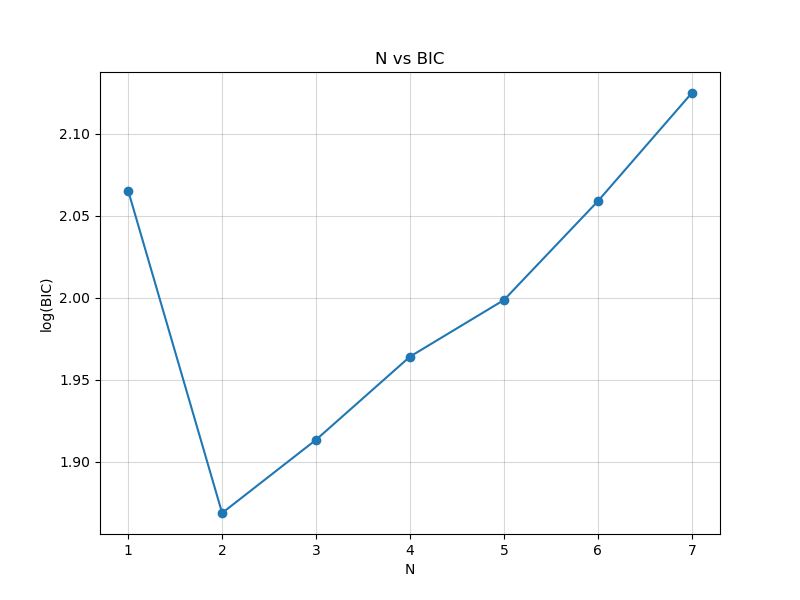

In [32]:
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('log(AIC)')
ax1.set_title('N vs AIC')
ax1.plot(n, np.log10(aic), marker = 'o')
plt.savefig('AIC_vs_N_log', bbox_inches='tight')

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('log(BIC)')
ax2.set_title('N vs BIC')
ax2.plot(n, np.log10(bic), marker = 'o')
plt.savefig('BIC_vs_N_log', bbox_inches='tight')